In [1]:
from torchvision.transforms import v2
from training_functions import GaussianBlurPatches
from medmnist import PathMNIST
import torch

tf_linear_data_aug = v2.Compose([
    v2.ToImage(),
    v2.RandomHorizontalFlip(0.5),
    v2.RandomVerticalFlip(0.5),
    v2.Pad(padding=16,padding_mode="reflect"),
    v2.RandomRotation(degrees=(0,360),interpolation=v2.InterpolationMode.BILINEAR),
    v2.CenterCrop(size=(64,64)),
    v2.ToDtype(torch.float32, scale=True),
])

tf_cross_data_aug = v2.Compose([
    v2.ToImage(),
    v2.RandomHorizontalFlip(0.5),
    v2.RandomVerticalFlip(0.5),
    v2.Pad(padding=32,padding_mode="reflect"),
    v2.RandomRotation(degrees=(0,360),interpolation=v2.InterpolationMode.BILINEAR),
    v2.CenterCrop(size=(72,72)),
    v2.RandomCrop(size=(64,64)),
    v2.ToDtype(torch.float32, scale=True),
    v2.ColorJitter(
        brightness=0.3,
        contrast=0.3,
        saturation=0.3,
        hue=0.1
    ),
    v2.GaussianNoise(sigma=0.01),
])

pad = 8
tf_full_data_aug = v2.Compose([
    v2.ToImage(),
    v2.RandomHorizontalFlip(0.5),
    v2.RandomVerticalFlip(0.5),
    v2.Pad(padding=32,padding_mode="symmetric"),
    v2.ElasticTransform(alpha=25.0,sigma=3.0),
    v2.RandomRotation(degrees=(0,360),interpolation=v2.InterpolationMode.BILINEAR),
    v2.CenterCrop(size=(64+(2*pad),64+(2*pad))),
    v2.RandomCrop(size=(64,64)),
    v2.ToDtype(torch.float32, scale=True),
    v2.ColorJitter(
        brightness=0.3,
        contrast=0.3,
        saturation=0.2,
        hue=0.02
    ),
    v2.RandomChoice(transforms=[
        v2.Compose([
            GaussianBlurPatches(kernel_size=25, sigma=8, p=0.5, scale=(0.1875, 0.25)),
            GaussianBlurPatches(kernel_size=17, sigma=6, p=0.5, scale=(0.075, 0.1)),
            GaussianBlurPatches(kernel_size=17, sigma=6, p=0.5, scale=(0.075, 0.1)),
            GaussianBlurPatches(kernel_size=13,  sigma=4, p=0.5, scale=(0.0375, 0.05)),
            GaussianBlurPatches(kernel_size=13,  sigma=4, p=0.5, scale=(0.0375, 0.05)),
            GaussianBlurPatches(kernel_size=13,  sigma=4, p=0.5, scale=(0.0375, 0.05)),
            GaussianBlurPatches(kernel_size=13,  sigma=4, p=0.5, scale=(0.0375, 0.05))
        ]),
        v2.GaussianBlur(kernel_size=7,sigma=2),
        v2.GaussianBlur(kernel_size=5,sigma=1)
    ],p=[0.75,0.125,0.125]),
    v2.Normalize(mean=(0.5,0.5,0.5),std=(0.5,0.5,0.5)),
    v2.GaussianNoise(sigma=0.02),
])

train_dataset = PathMNIST(root="./data/",split="train",transform=tf_full_data_aug,download=True,size=64)

In [2]:
from torch.utils.data import RandomSampler
from torch.utils.data import DataLoader

test_samples = RandomSampler(train_dataset,num_samples=1)
test_loader = DataLoader(train_dataset, batch_size=1, sampler=test_samples)

(64, 64, 3)


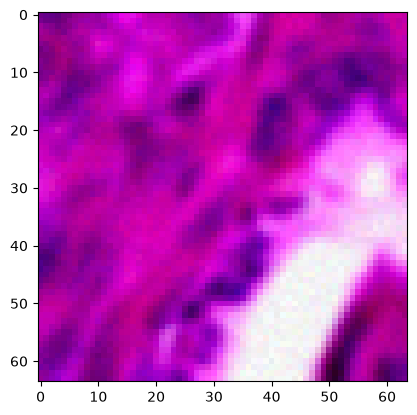

In [61]:
import matplotlib.pyplot as plt
import numpy as np

image_raw = [ img for img,lbl in test_loader]

image = np.clip(np.reshape(image_raw,(3,64,64)).transpose(1, 2, 0), 0, 1)
print(image.shape)
plt.imshow(image)
plt.show()